In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score, accuracy_score, auc, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Task 1 — Persiapan

In [2]:
df = pd.read_csv('./telco.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df['TotalCharges'].replace(' ', float('nan'), inplace= True)
df.dropna(subset='TotalCharges',inplace=True)
df['TotalCharges'] = df['TotalCharges'].astype(float)

D:\Users\bsi80273\AppData\Local\Temp\ipykernel_26476\3475724853.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].replace(' ', float('nan'), inplace= True)


In [5]:
df.drop('customerID', axis = 1, inplace = True)

In [6]:
standart_scaler = StandardScaler()
cols_to_encode = df.select_dtypes('number').columns
df[cols_to_encode] = standart_scaler.fit_transform(df[cols_to_encode])

In [7]:
df['Churn'] = df['Churn'].map({'Yes':0, 'No':1})

In [8]:
one_encoder = OneHotEncoder()
cols_to_encode = df.select_dtypes('object').columns

one_encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_array = one_encoder.fit_transform(df[cols_to_encode])
encoded_df = pd.DataFrame(
    encoded_array,
    columns=one_encoder.get_feature_names_out(cols_to_encode),
    index=df.index
)

df = df.drop(columns=cols_to_encode).join(encoded_df)

# Task 2 — Logistic Regression Baseline



In [9]:
X = df.drop('Churn', axis = 1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 ,random_state=42)

In [10]:
model = LogisticRegression(solver='lbfgs', max_iter=1000)

In [11]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Text(0.5, 1.0, 'Confusion Matrix — Telco Churn')

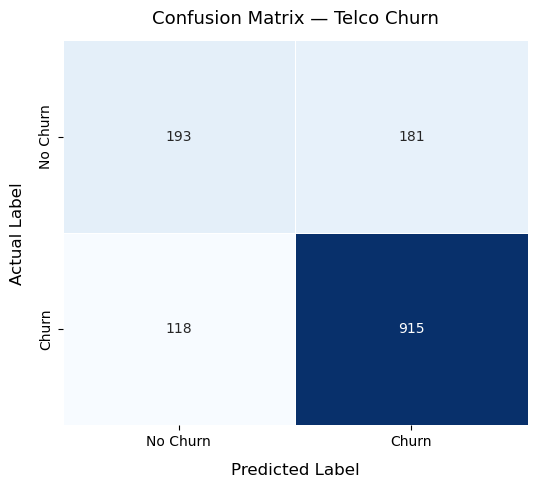

In [12]:
cm = confusion_matrix(y_test, y_pred)
labels = ['No Churn', 'Churn']

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    linecolor='white',
    cbar=False,
    ax=ax
)

ax.set_xlabel('Predicted Label', fontsize=12, labelpad=10)
ax.set_ylabel('Actual Label', fontsize=12, labelpad=10)
ax.set_title('Confusion Matrix — Telco Churn', fontsize=13, pad=12)

In [13]:
print(classification_report(y_test, y_pred, target_names=labels))

              precision    recall  f1-score   support

    No Churn       0.62      0.52      0.56       374
       Churn       0.83      0.89      0.86      1033

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



Model hanya memiliki kemampuan yang baik untuk memprediksi "No Churn". Namun memiliki kemampuan yang kurang baik dalam memprediksi churn. Hal ini dikarenakan data yang tidak balanace pada data training, dimana data "No Churn" sebanyak 1033 dan 344 di data "Churn".

- Jika bisnis ingin memprediksi pelanggan chrun, maka model ini masih belum baik untuk diimplementasikan.
- Namun akan siap digunakan jika untuk memprediksi customer loyal atau "No Churn"

# Task 3 — Perbandingan Regularization



          PERBANDINGAN MODEL LOGISTIC REGRESSION
Penalty     C  Train Acc  Test Acc  CV Score  Zero Coefs
     L1  0.01     0.7982    0.7839    0.7968          21
     L1   0.1     0.8044    0.7910    0.8037          12
     L1     1     0.8087    0.7889    0.8057           1
     L1    10     0.8089    0.7896    0.8076           0
     L2  0.01     0.8060    0.7903    0.8044           0
     L2   0.1     0.8066    0.7910    0.8060           0
     L2     1     0.8089    0.7875    0.8064           0
     L2    10     0.8085    0.7896    0.8069           0
   None     -     0.8085    0.7882    0.8068           0


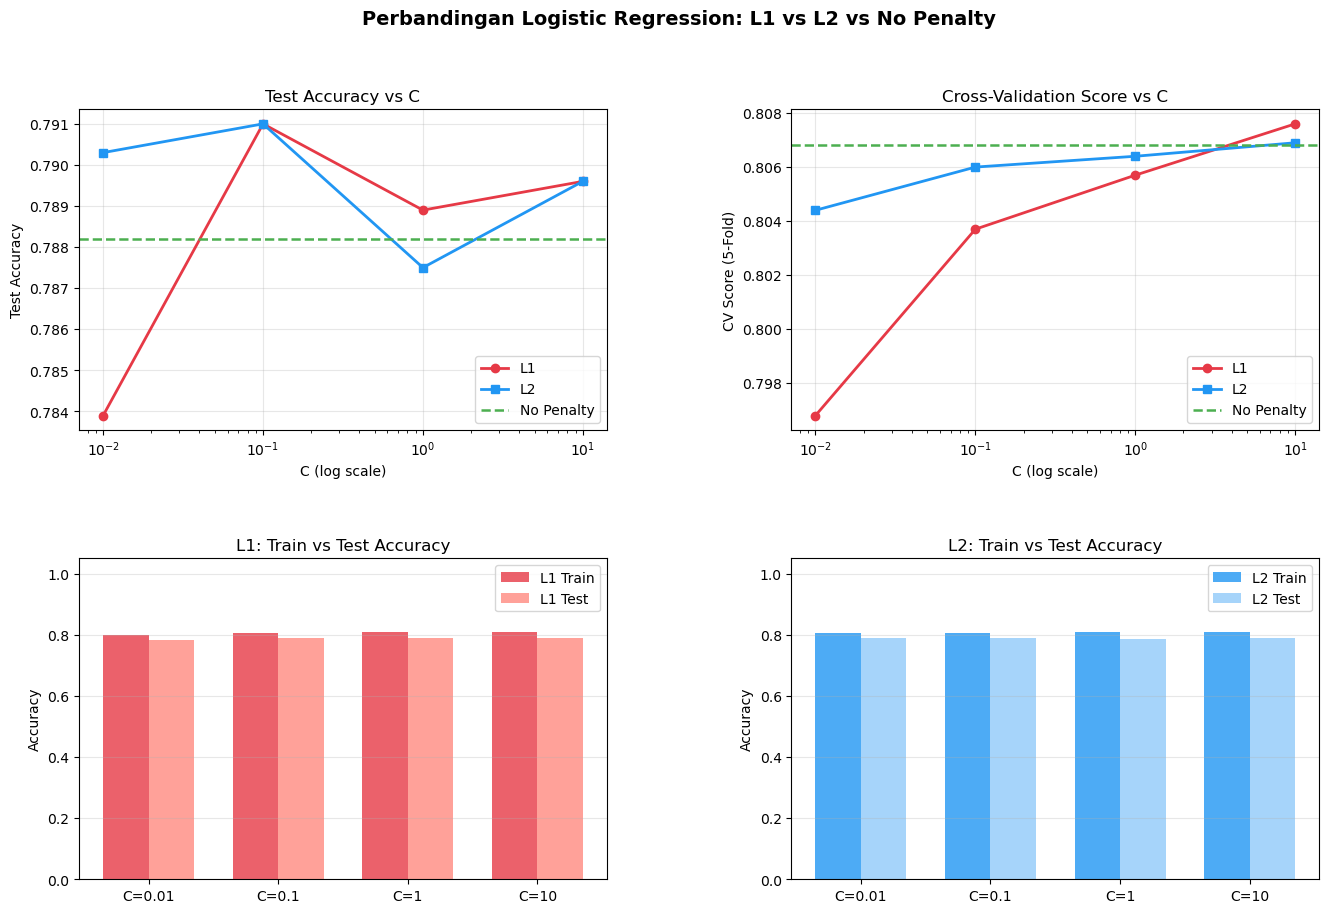

In [14]:
C_values = [0.01, 0.1, 1, 10]
results = []

# ── 1. L1 Regularization (Lasso) ─────────
for C in C_values:
    model = LogisticRegression(penalty='l1', solver='liblinear', C=C, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))
    cv_score  = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean()
    n_zero    = np.sum(model.coef_ == 0)          # sparsity check
    
    results.append({
        'Penalty': 'L1', 'C': C,
        'Train Acc': train_acc, 'Test Acc': test_acc,
        'CV Score': cv_score, 'Zero Coefs': n_zero
    })

# ── 2. L2 Regularization (Ridge) ─────────
for C in C_values:
    model = LogisticRegression(penalty='l2', solver='lbfgs', C=C, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))
    cv_score  = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean()
    n_zero    = np.sum(model.coef_ == 0)
    
    results.append({
        'Penalty': 'L2', 'C': C,
        'Train Acc': train_acc, 'Test Acc': test_acc,
        'CV Score': cv_score, 'Zero Coefs': n_zero
    })

# ── 3. No Regularization ─────────────────
model_none = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000, random_state=42)
model_none.fit(X_train, y_train)

train_acc = accuracy_score(y_train, model_none.predict(X_train))
test_acc  = accuracy_score(y_test,  model_none.predict(X_test))
cv_score  = cross_val_score(model_none, X_train, y_train, cv=5, scoring='accuracy').mean()

results.append({
    'Penalty': 'None', 'C': '-',
    'Train Acc': train_acc, 'Test Acc': test_acc,
    'CV Score': cv_score, 'Zero Coefs': 0
})

# ── Tabel Hasil ───────────────────────────
df_results = pd.DataFrame(results)
df_results[['Train Acc','Test Acc','CV Score']] = \
    df_results[['Train Acc','Test Acc','CV Score']].round(4)

print("=" * 65)
print("          PERBANDINGAN MODEL LOGISTIC REGRESSION")
print("=" * 65)
print(df_results.to_string(index=False))
print("=" * 65)

# ── Visualisasi ───────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Perbandingan Logistic Regression: L1 vs L2 vs No Penalty',
             fontsize=14, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

l1 = df_results[df_results['Penalty'] == 'L1']
l2 = df_results[df_results['Penalty'] == 'L2']
none_row = df_results[df_results['Penalty'] == 'None'].iloc[0]
x = np.arange(len(C_values))
w = 0.35

# Plot 1: Test Accuracy vs C
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(C_values, l1['Test Acc'], 'o-', color='#E63946', label='L1', lw=2)
ax1.plot(C_values, l2['Test Acc'], 's-', color='#2196F3', label='L2', lw=2)
ax1.axhline(none_row['Test Acc'], color='#4CAF50', ls='--', lw=1.8, label='No Penalty')
ax1.set_xscale('log')
ax1.set_xlabel('C (log scale)')
ax1.set_ylabel('Test Accuracy')
ax1.set_title('Test Accuracy vs C')
ax1.legend(); ax1.grid(alpha=0.3)

# Plot 2: CV Score vs C
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(C_values, l1['CV Score'], 'o-', color='#E63946', label='L1', lw=2)
ax2.plot(C_values, l2['CV Score'], 's-', color='#2196F3', label='L2', lw=2)
ax2.axhline(none_row['CV Score'], color='#4CAF50', ls='--', lw=1.8, label='No Penalty')
ax2.set_xscale('log')
ax2.set_xlabel('C (log scale)')
ax2.set_ylabel('CV Score (5-Fold)')
ax2.set_title('Cross-Validation Score vs C')
ax2.legend(); ax2.grid(alpha=0.3)

# Plot 3: Train vs Test Accuracy (grouped bar)
ax3 = fig.add_subplot(gs[1, 0])
bars1 = ax3.bar(x - w/2, l1['Train Acc'], w, label='L1 Train', color='#E63946', alpha=0.8)
bars2 = ax3.bar(x + w/2, l1['Test Acc'],  w, label='L1 Test',  color='#FF8A80', alpha=0.8)
ax3.set_xticks(x); ax3.set_xticklabels([f'C={c}' for c in C_values])
ax3.set_ylabel('Accuracy')
ax3.set_title('L1: Train vs Test Accuracy')
ax3.legend(); ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim(0, 1.05)

ax4 = fig.add_subplot(gs[1, 1])
bars3 = ax4.bar(x - w/2, l2['Train Acc'], w, label='L2 Train', color='#2196F3', alpha=0.8)
bars4 = ax4.bar(x + w/2, l2['Test Acc'],  w, label='L2 Test',  color='#90CAF9', alpha=0.8)
ax4.set_xticks(x); ax4.set_xticklabels([f'C={c}' for c in C_values])
ax4.set_ylabel('Accuracy')
ax4.set_title('L2: Train vs Test Accuracy')
ax4.legend(); ax4.grid(axis='y', alpha=0.3)
ax4.set_ylim(0, 1.05)

plt.savefig('lr_regularization_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


L1 menghasilkan koefisien nol, dikarenakan sifat L1 penalty sendiri yang menghapus weigh pada fitur yang dikiranya tidak ada korelasi nya. Konsekuensi yang diterima dapat menjadi 2 kemungkinan:
- Model lebih cepat pada fase training karena membuang fitur yang tidak diperlukan
- Jika salah dalam menghapus weight pada fitur, ada kemungkinan untuk kehilangan informasi yang mungkin penting bagi model.

  Top 10 Fitur — L2 Logistic Reg (C=10)
                       Feature  Coefficient  Abs_Coef
   InternetService_Fiber optic    -1.858465  1.858465
                        tenure     1.487440  1.487440
             Contract_Two year     1.342155  1.342155
                MonthlyCharges     1.302287  1.302287
MultipleLines_No phone service     0.921973  0.921973
             Contract_One year     0.770984  0.770984
                  TotalCharges    -0.738703  0.738703
              PhoneService_Yes     0.684506  0.684506
           StreamingMovies_Yes    -0.675750  0.675750
               StreamingTV_Yes    -0.655579  0.655579


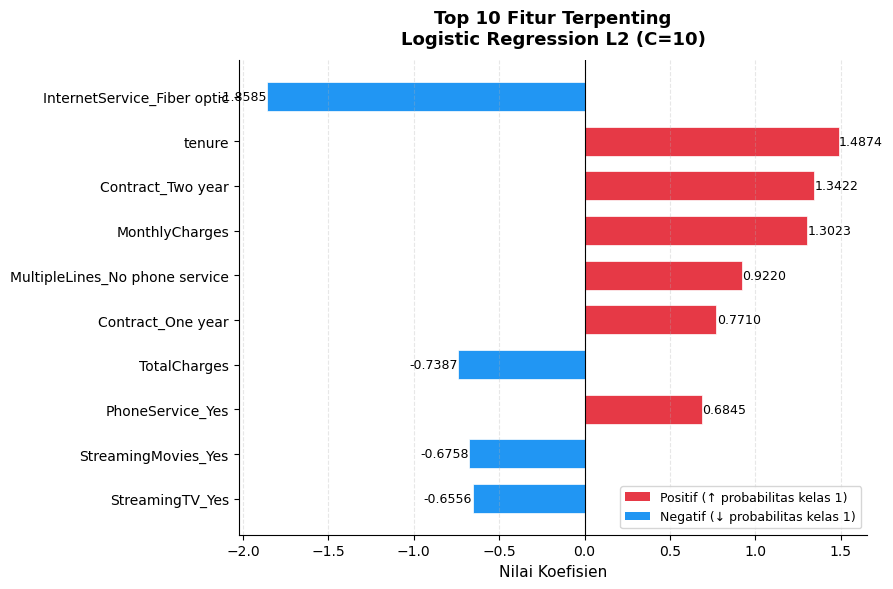

In [15]:
# ── Train model L2, C=10 ──────────────────
best_model = LogisticRegression(penalty='l2', solver='lbfgs', C=10, max_iter=1000, random_state=42)
best_model.fit(X_train, y_train)

# ── Ambil koefisien ───────────────────────
# Jika binary classification → coef_ shape: (1, n_features)
# Jika multiclass            → coef_ shape: (n_classes, n_features)
coef = best_model.coef_[0]          # ambil kelas pertama / gunakan [0] untuk binary

feature_names = X_train.columns.tolist()   # atau list nama fitur kamu

df_coef = pd.DataFrame({
    'Feature'  : feature_names,
    'Coefficient': coef,
    'Abs_Coef' : np.abs(coef)
}).sort_values('Abs_Coef', ascending=False).reset_index(drop=True)

top10 = df_coef.head(10)

print("=" * 45)
print("  Top 10 Fitur — L2 Logistic Reg (C=10)")
print("=" * 45)
print(top10[['Feature', 'Coefficient', 'Abs_Coef']].to_string(index=False))
print("=" * 45)

# ── Visualisasi horizontal bar ────────────
fig, ax = plt.subplots(figsize=(9, 6))

colors = ['#E63946' if v > 0 else '#2196F3' for v in top10['Coefficient']]

bars = ax.barh(
    top10['Feature'][::-1],
    top10['Coefficient'][::-1],
    color=colors[::-1],
    edgecolor='white', linewidth=0.5,
    height=0.65
)

# Nilai di ujung bar
for bar, val in zip(bars, top10['Coefficient'][::-1]):
    offset = 0.002 if val >= 0 else -0.002
    ha     = 'left'  if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha=ha, fontsize=9)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Nilai Koefisien', fontsize=11)
ax.set_title('Top 10 Fitur Terpenting\nLogistic Regression L2 (C=10)',
             fontsize=13, fontweight='bold', pad=12)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#E63946', label='Positif (↑ probabilitas kelas 1)'),
                   Patch(facecolor='#2196F3', label='Negatif (↓ probabilitas kelas 1)')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('top10_coef_l2_c10.png', dpi=150, bbox_inches='tight')
plt.show()

# Task 4 — ROC Curve dan AUC

AUC Score : 0.8318
Jumlah threshold yang dievaluasi: 414


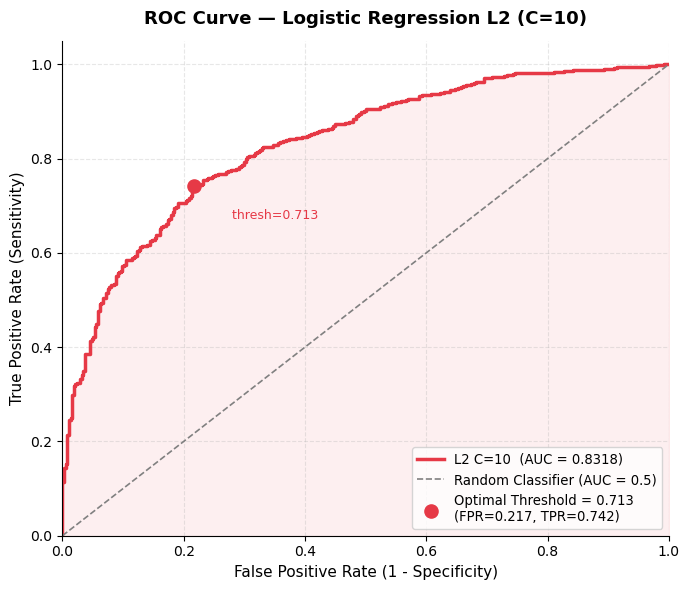

In [16]:
# ── 1. Predict Probability ────────────────
y_prob = best_model.predict_proba(X_test)[:, 1]   # probabilitas kelas positif (kolom index 1)

# ── 2. Hitung ROC Curve & AUC ─────────────
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print(f"AUC Score : {roc_auc:.4f}")
print(f"Jumlah threshold yang dievaluasi: {len(thresholds)}")

# ── 3. Plot ROC Curve ─────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

# ROC curve utama
ax.plot(fpr, tpr,
        color='#E63946', lw=2.5,
        label=f'L2 C=10  (AUC = {roc_auc:.4f})')

# Garis diagonal baseline (random classifier)
ax.plot([0, 1], [0, 1],
        color='gray', lw=1.2, linestyle='--', label='Random Classifier (AUC = 0.5)')

# Titik optimal: Youden Index (max TPR - FPR)
youden_idx  = np.argmax(tpr - fpr)
opt_fpr     = fpr[youden_idx]
opt_tpr     = tpr[youden_idx]
opt_thresh  = thresholds[youden_idx]

ax.scatter(opt_fpr, opt_tpr, color='#E63946', s=90, zorder=5,
           label=f'Optimal Threshold = {opt_thresh:.3f}\n(FPR={opt_fpr:.3f}, TPR={opt_tpr:.3f})')
ax.annotate(f'  thresh={opt_thresh:.3f}',
            xy=(opt_fpr, opt_tpr), fontsize=9, color='#E63946',
            xytext=(opt_fpr + 0.05, opt_tpr - 0.07))

# Area under curve (shading)
ax.fill_between(fpr, tpr, alpha=0.08, color='#E63946')

# Formatting
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
ax.set_ylabel('True Positive Rate (Sensitivity)',       fontsize=11)
ax.set_title('ROC Curve — Logistic Regression L2 (C=10)',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=9.5)
ax.grid(alpha=0.3, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('roc_curve_l2_c10.png', dpi=150, bbox_inches='tight')
plt.show()

AUC — L2 C=10   : 0.8318
AUC — Default   : 0.8319
Δ AUC           : -0.0001


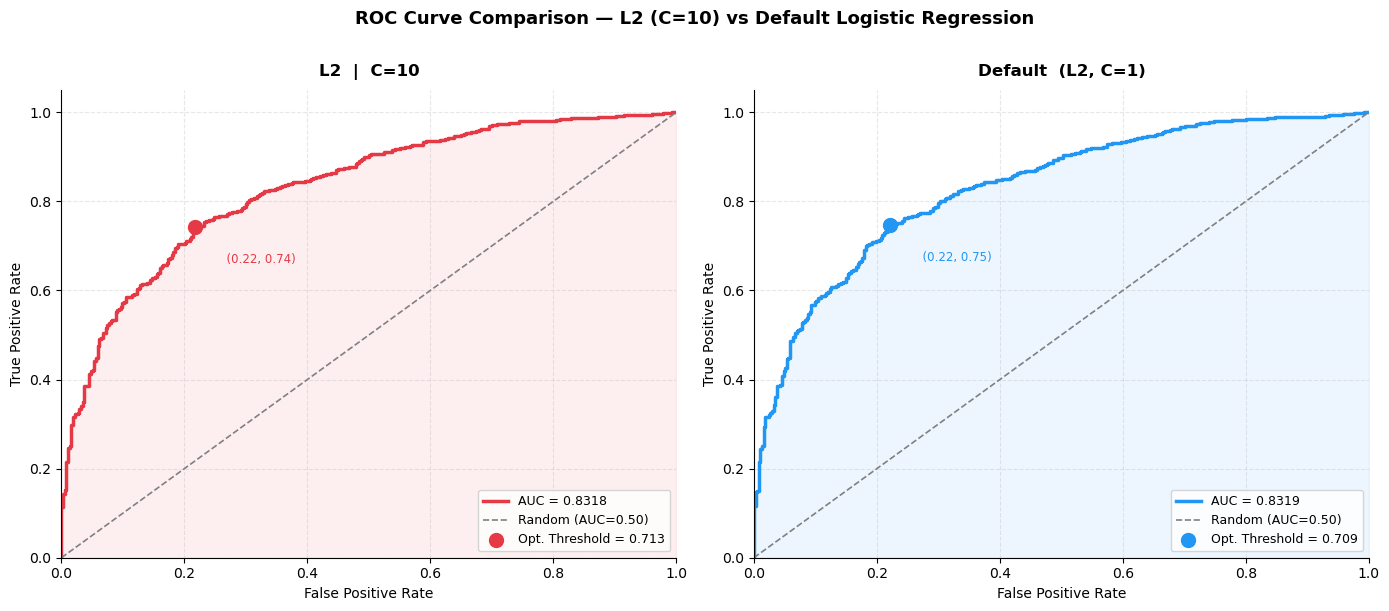


         RINGKASAN PERBANDINGAN
Metric                  L2 C=10  Default
----------------------------------------
AUC                      0.8318   0.8319
Optimal Threshold         0.713    0.709
TPR @ optimal             0.742    0.746
FPR @ optimal             0.217    0.222


In [17]:
# ── 1. Model Default ──────────────────────
model_default = LogisticRegression(solver='lbfgs', random_state=42, max_iter=1000)
model_default.fit(X_train, y_train)

# ── 2. Predict Proba ──────────────────────
y_prob_best    = best_model.predict_proba(X_test)[:, 1]   # L2, C=10
y_prob_default = model_default.predict_proba(X_test)[:, 1]

# ── 3. ROC & AUC ─────────────────────────
fpr_best, tpr_best, thresh_best       = roc_curve(y_test, y_prob_best)
fpr_def,  tpr_def,  thresh_def        = roc_curve(y_test, y_prob_default)

auc_best    = auc(fpr_best, tpr_best)
auc_default = auc(fpr_def,  tpr_def)

# Youden Index (optimal threshold)
def youden_point(fpr, tpr, thresh):
    idx = np.argmax(tpr - fpr)
    return fpr[idx], tpr[idx], thresh[idx]

opt_fpr_b, opt_tpr_b, opt_thresh_b = youden_point(fpr_best, tpr_best, thresh_best)
opt_fpr_d, opt_tpr_d, opt_thresh_d = youden_point(fpr_def,  tpr_def,  thresh_def)

print(f"AUC — L2 C=10   : {auc_best:.4f}")
print(f"AUC — Default   : {auc_default:.4f}")
print(f"Δ AUC           : {auc_best - auc_default:+.4f}")

# ── 4. Plot Side by Side ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('ROC Curve Comparison — L2 (C=10) vs Default Logistic Regression',
             fontsize=13, fontweight='bold', y=1.01)

configs = [
    {
        'ax'        : axes[0],
        'fpr'       : fpr_best,
        'tpr'       : tpr_best,
        'auc'       : auc_best,
        'opt_fpr'   : opt_fpr_b,
        'opt_tpr'   : opt_tpr_b,
        'opt_thresh': opt_thresh_b,
        'color'     : '#E63946',
        'title'     : 'L2  |  C=10',
    },
    {
        'ax'        : axes[1],
        'fpr'       : fpr_def,
        'tpr'       : tpr_def,
        'auc'       : auc_default,
        'opt_fpr'   : opt_fpr_d,
        'opt_tpr'   : opt_tpr_d,
        'opt_thresh': opt_thresh_d,
        'color'     : '#2196F3',
        'title'     : 'Default  (L2, C=1)',
    },
]

for cfg in configs:
    ax = cfg['ax']

    # ROC curve + shading
    ax.plot(cfg['fpr'], cfg['tpr'],
            color=cfg['color'], lw=2.5,
            label=f"AUC = {cfg['auc']:.4f}")
    ax.fill_between(cfg['fpr'], cfg['tpr'], alpha=0.08, color=cfg['color'])

    # Baseline
    ax.plot([0, 1], [0, 1], color='gray', lw=1.2, ls='--', label='Random (AUC=0.50)')

    # Titik optimal
    ax.scatter(cfg['opt_fpr'], cfg['opt_tpr'],
               color=cfg['color'], s=100, zorder=5,
               label=f"Opt. Threshold = {cfg['opt_thresh']:.3f}")
    ax.annotate(f"  ({cfg['opt_fpr']:.2f}, {cfg['opt_tpr']:.2f})",
                xy=(cfg['opt_fpr'], cfg['opt_tpr']),
                fontsize=8.5, color=cfg['color'],
                xytext=(cfg['opt_fpr'] + 0.04, cfg['opt_tpr'] - 0.08))

    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=10)
    ax.set_ylabel('True Positive Rate',  fontsize=10)
    ax.set_title(cfg['title'], fontsize=12, fontweight='bold', pad=10)
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.3, ls='--')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# ── 5. Ringkasan ──────────────────────────
print("\n" + "=" * 40)
print("         RINGKASAN PERBANDINGAN")
print("=" * 40)
print(f"{'Metric':<22} {'L2 C=10':>8} {'Default':>8}")
print("-" * 40)
print(f"{'AUC':<22} {auc_best:>8.4f} {auc_default:>8.4f}")
print(f"{'Optimal Threshold':<22} {opt_thresh_b:>8.3f} {opt_thresh_d:>8.3f}")
print(f"{'TPR @ optimal':<22} {opt_tpr_b:>8.3f} {opt_tpr_d:>8.3f}")
print(f"{'FPR @ optimal':<22} {opt_fpr_b:>8.3f} {opt_fpr_d:>8.3f}")
print("=" * 40)

Model dengan L2 dan C=10 tampak tidak memiliki perbedaan yang signifikan pada model default. dikarenakan default dari logistic regression sendiri sudah menggunakan L2.